In [2]:
import csv
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PLAYERS = "../data/player_features.csv"

prediction_files = [os.path.join("../predictions", filename) for filename in os.listdir("../predictions")]
embedding_files = [os.path.join("../embeddings", filename) for filename in os.listdir("../embeddings")]

print("Prediction files found: ", prediction_files)
print("Embedding files found: ", embedding_files)

Prediction files found:  ['../predictions/Linear.csv', '../predictions/GAT.csv', '../predictions/GraphSage.csv']
Embedding files found:  ['../embeddings/Linear.csv', '../embeddings/GAT.csv', '../embeddings/GraphSage.csv']


In [10]:
def traditional_two_way_eval(filename):
    """
    Calculates success of row twice, once for if forward pred is correct 
    and once for if reverse pred is correct in the traditional eval technique.

    All labels are 1 in the prediction files.
    
    Args:
        filename: Path to the CSV file
        
    Returns:
        Percentage of correct rows
    """
    with open(filename, 'r') as f:
        reader = csv.DictReader(f)
        total = 0
        count = 0
        
        for row in reader:
            pred = float(row['pred'])
            rev_pred = float(row['reverse_pred'])
            label = int(row['label'])
            
            if pred > 0.5 and label == 1:
                count += 1
            if rev_pred < 0.5 and label == 1:
                count += 1
            total += 2
    
    return round(count / total * 100, 2)

for filename in prediction_files:
    print(f"For file {filename}:\t {traditional_two_way_eval(filename)}% correct")

For file ../predictions/Linear.csv:	 62.81% correct
For file ../predictions/GAT.csv:	 64.73% correct
For file ../predictions/GraphSage.csv:	 61.79% correct


In [11]:
def comparative_eval(filename):
    """
    Implements different eval technique comparing
    probability of one direction vs the other, rather than
    probability of each direction vs a threshold of 0.5.

    All labes are 1 in the prediction files.
    
    Args:
        filename: Path to the CSV file
        
    Returns:
        Percentage of rows where pred > reverse_pred
    """
    with open(filename, 'r') as f:
        reader = csv.DictReader(f)
        total = 0
        count = 0
        
        for row in reader:
            pred = float(row['pred'])
            reverse_pred = float(row['reverse_pred'])
            
            if (pred > reverse_pred):
                count += 1
            total += 1
    
    return round(count / total * 100, 2)

for filename in prediction_files:
    print(f"For file {filename}:\t {comparative_eval(filename)}% correct")

For file ../predictions/Linear.csv:	 62.87% correct
For file ../predictions/GAT.csv:	 65.35% correct
For file ../predictions/GraphSage.csv:	 62.87% correct


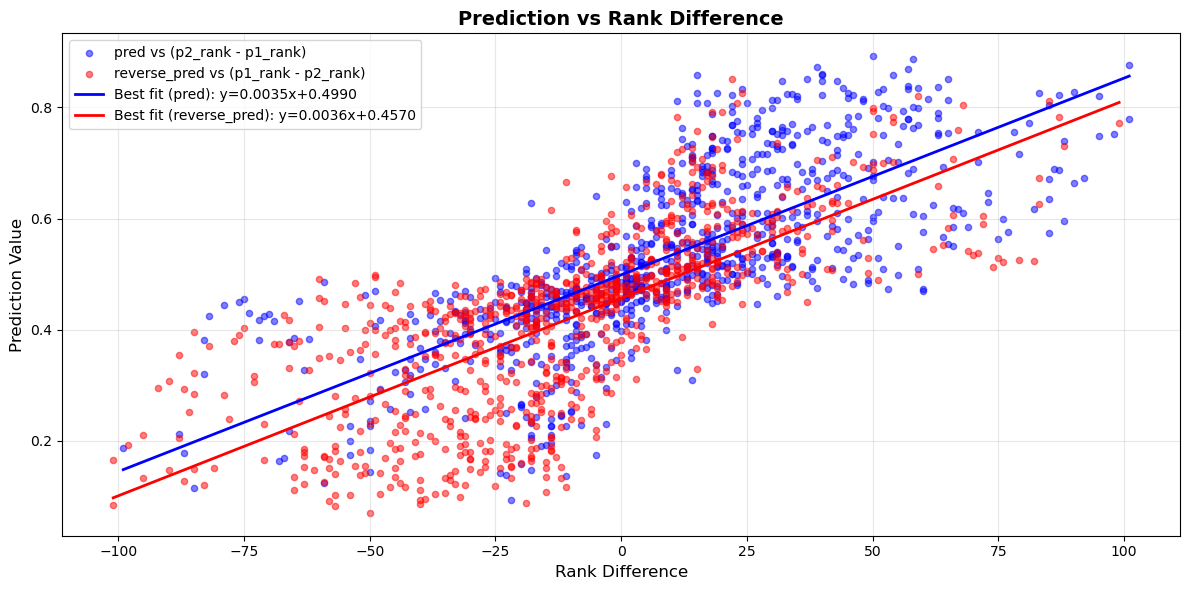

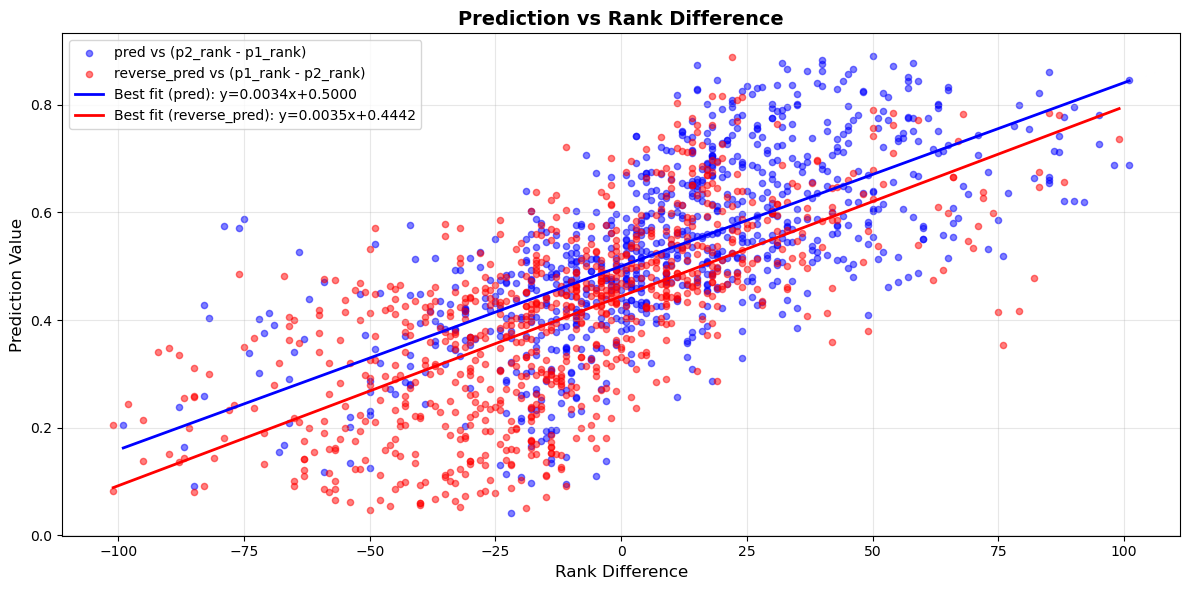

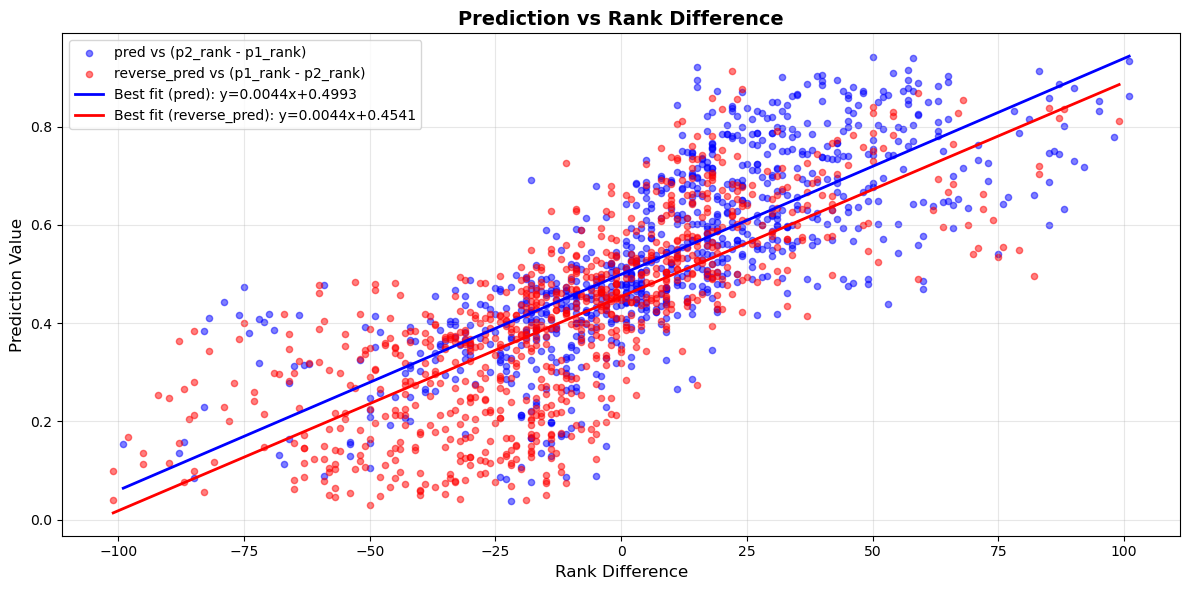

In [12]:
def plot_confidence_by_rank_difference(filename):
    """
    Plot scatter graph with line of best fit:
    - pred vs (p2_rank - p1_rank)
    - reverse_pred vs (p1_rank - p2_rank)
    
    Args:
        predictions_file: Path to predictions CSV
        players_file: Path to players CSV
    """
    # Load data
    preds = pd.read_csv(filename)
    players = pd.read_csv(PLAYERS)
    
    # Create a dictionary for quick rank lookup
    rank_dict = dict(zip(players['player_id'], players['current_rank']))
    
    # Get ranks for p1 and p2
    preds['p1_rank'] = preds['p1_id'].map(rank_dict)
    preds['p2_rank'] = preds['p2_id'].map(rank_dict)
    
    # Calculate rank differences
    preds['p2_minus_p1'] = preds['p2_rank'] - preds['p1_rank']
    preds['p1_minus_p2'] = preds['p1_rank'] - preds['p2_rank']
    
    # Remove rows with missing ranks
    preds = preds.dropna(subset=['p1_rank', 'p2_rank'])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot pred vs (p2_rank - p1_rank)
    ax.scatter(preds['p2_minus_p1'], preds['pred'], 
               alpha=0.5, label='pred vs (p2_rank - p1_rank)', 
               color='blue', s=20)
    
    # Plot reverse_pred vs (p1_rank - p2_rank)
    ax.scatter(preds['p1_minus_p2'], preds['reverse_pred'], 
               alpha=0.5, label='reverse_pred vs (p1_rank - p2_rank)', 
               color='red', s=20)
    
    # Calculate and plot line of best fit for pred
    z1 = np.polyfit(preds['p2_minus_p1'], preds['pred'], 1)
    p1 = np.poly1d(z1)
    x_line = np.linspace(preds['p2_minus_p1'].min(), preds['p2_minus_p1'].max(), 100)
    ax.plot(x_line, p1(x_line), 'b-', linewidth=2, 
            label=f'Best fit (pred): y={z1[0]:.4f}x+{z1[1]:.4f}')
    
    # Calculate and plot line of best fit for reverse_pred
    z2 = np.polyfit(preds['p1_minus_p2'], preds['reverse_pred'], 1)
    p2 = np.poly1d(z2)
    x_line2 = np.linspace(preds['p1_minus_p2'].min(), preds['p1_minus_p2'].max(), 100)
    ax.plot(x_line2, p2(x_line2), 'r-', linewidth=2, 
            label=f'Best fit (reverse_pred): y={z2[0]:.4f}x+{z2[1]:.4f}')
    
    ax.set_xlabel('Rank Difference', fontsize=12)
    ax.set_ylabel('Prediction Value', fontsize=12)
    ax.set_title('Prediction vs Rank Difference', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

for filename in prediction_files:
    fig = plot_confidence_by_rank_difference(filename)
    plt.show()

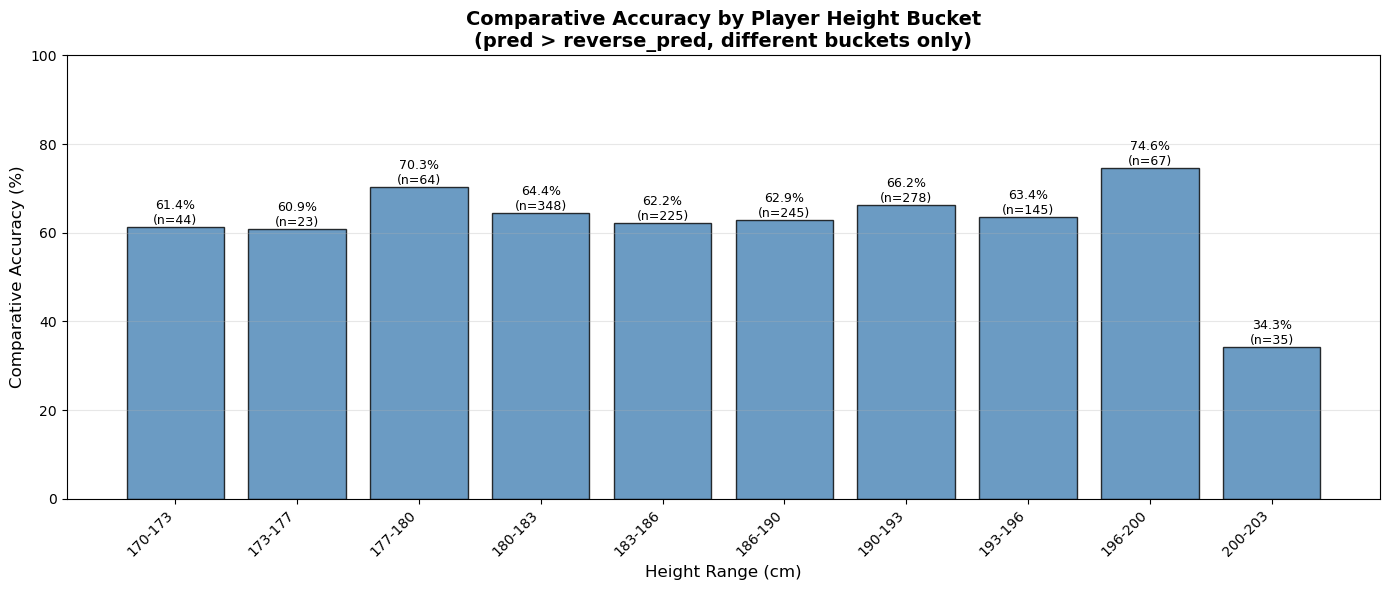

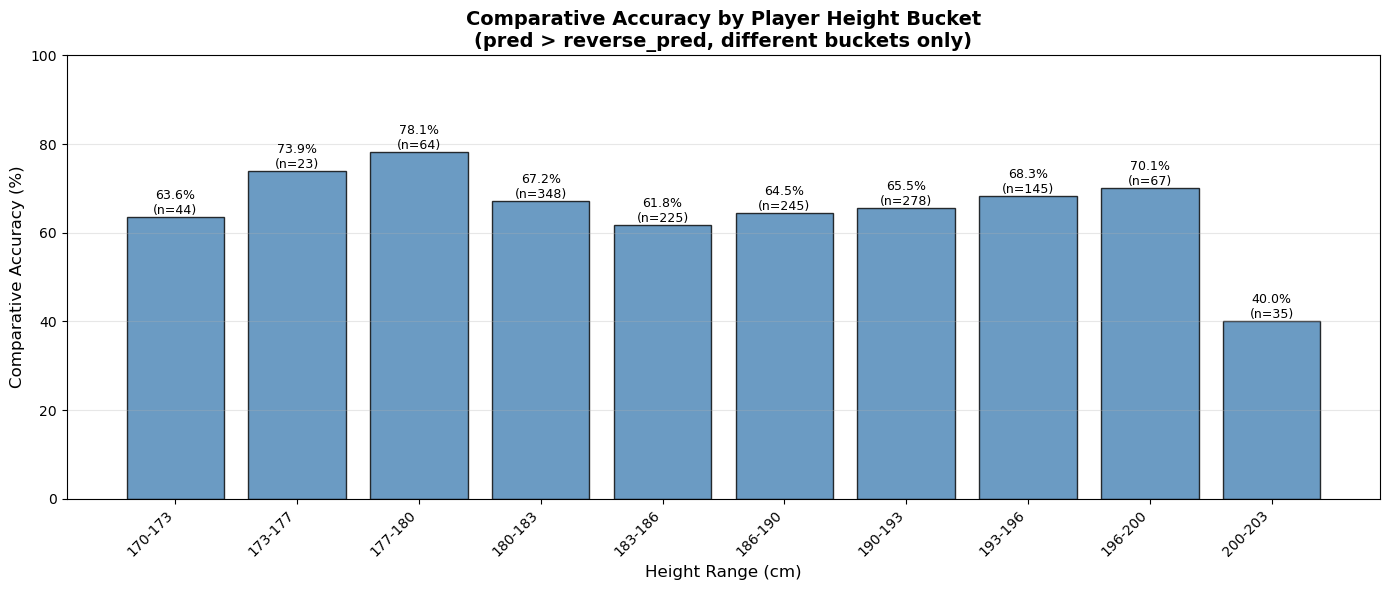

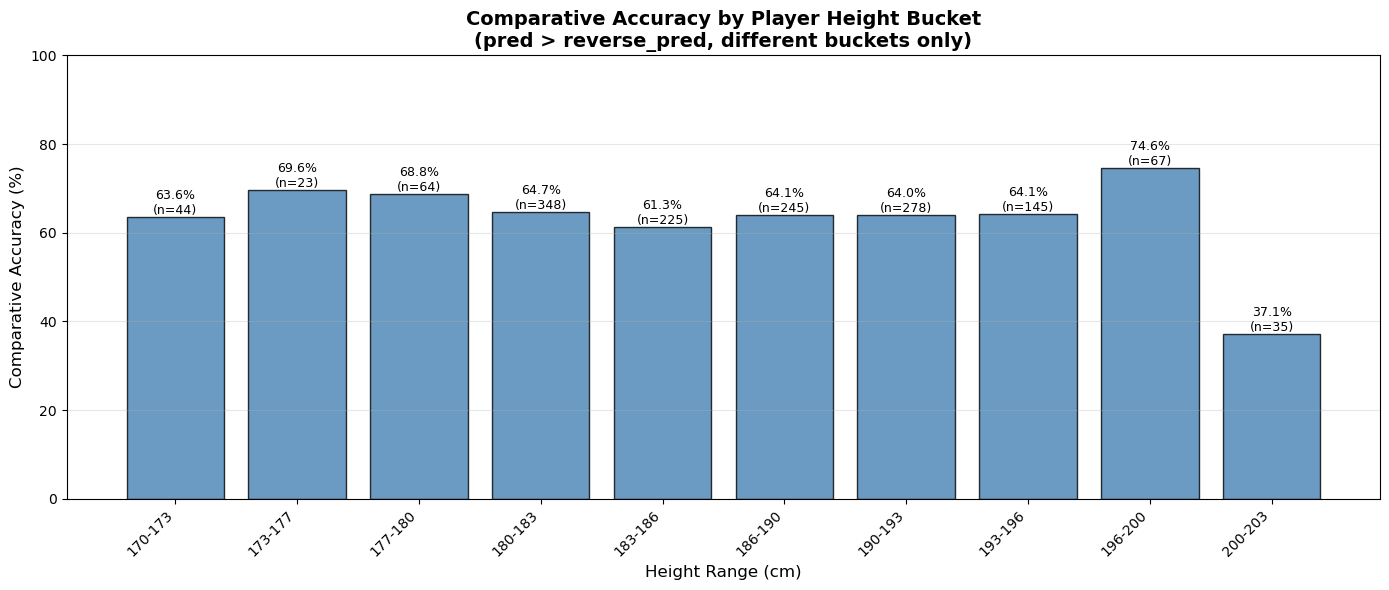

In [13]:
def plot_height_comparative_accuracy(predictions_file):
    """
    Partition players by height into 10 equal groups and calculate 
    comparative accuracy (pred > reverse_pred) for each height bucket.
    
    Args:
        predictions_file: Path to predictions CSV
    """
    # Load data
    preds = pd.read_csv(predictions_file)
    players = pd.read_csv(PLAYERS)
    
    # Create height lookup dictionary
    height_dict = dict(zip(players['player_id'], players['height']))
    
    # Get heights for p1 and p2
    preds['p1_height'] = preds['p1_id'].map(height_dict)
    preds['p2_height'] = preds['p2_id'].map(height_dict)
    
    # Remove rows with missing heights
    preds = preds.dropna(subset=['p1_height', 'p2_height'])
    
    # Determine if prediction was correct (pred > reverse_pred)
    preds['correct'] = preds['pred'] > preds['reverse_pred']
    
    # Create 10 equal height buckets
    min_height = players['height'].min()
    max_height = players['height'].max()
    bucket_edges = np.linspace(min_height, max_height, 11)
    bucket_labels = [f"{bucket_edges[i]:.0f}-{bucket_edges[i+1]:.0f}" 
                     for i in range(10)]
    
    # Initialize accuracy tracking for each bucket
    bucket_correct = {label: 0 for label in bucket_labels}
    bucket_total = {label: 0 for label in bucket_labels}
    
    # For each prediction, assign to buckets for both players
    for _, row in preds.iterrows():
        # Find bucket for p1
        p1_bucket_idx = np.digitize(row['p1_height'], bucket_edges) - 1
        p1_bucket_idx = max(0, min(p1_bucket_idx, 9))  # Clamp to valid range
        
        # Find bucket for p2
        p2_bucket_idx = np.digitize(row['p2_height'], bucket_edges) - 1
        p2_bucket_idx = max(0, min(p2_bucket_idx, 9))  # Clamp to valid range
        
        # Only count if players are in different buckets
        if p1_bucket_idx != p2_bucket_idx:
            is_correct = row['correct']
            
            # Add to both buckets
            bucket_total[bucket_labels[p1_bucket_idx]] += 1
            bucket_total[bucket_labels[p2_bucket_idx]] += 1
            
            if is_correct:
                bucket_correct[bucket_labels[p1_bucket_idx]] += 1
                bucket_correct[bucket_labels[p2_bucket_idx]] += 1
    
    # Calculate accuracy for each bucket
    accuracies = []
    for label in bucket_labels:
        if bucket_total[label] > 0:
            acc = (bucket_correct[label] / bucket_total[label]) * 100
        else:
            acc = 0
        accuracies.append(acc)
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x_pos = np.arange(len(bucket_labels))
    bars = ax.bar(x_pos, accuracies, color='steelblue', alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1f}%\n(n={bucket_total[bucket_labels[i]]})',
                ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Height Range (cm)', fontsize=12)
    ax.set_ylabel('Comparative Accuracy (%)', fontsize=12)
    ax.set_title('Comparative Accuracy by Player Height Bucket\n(pred > reverse_pred, different buckets only)', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bucket_labels, rotation=45, ha='right')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig

for filename in prediction_files:
    fig = plot_height_comparative_accuracy(filename)
    plt.show()

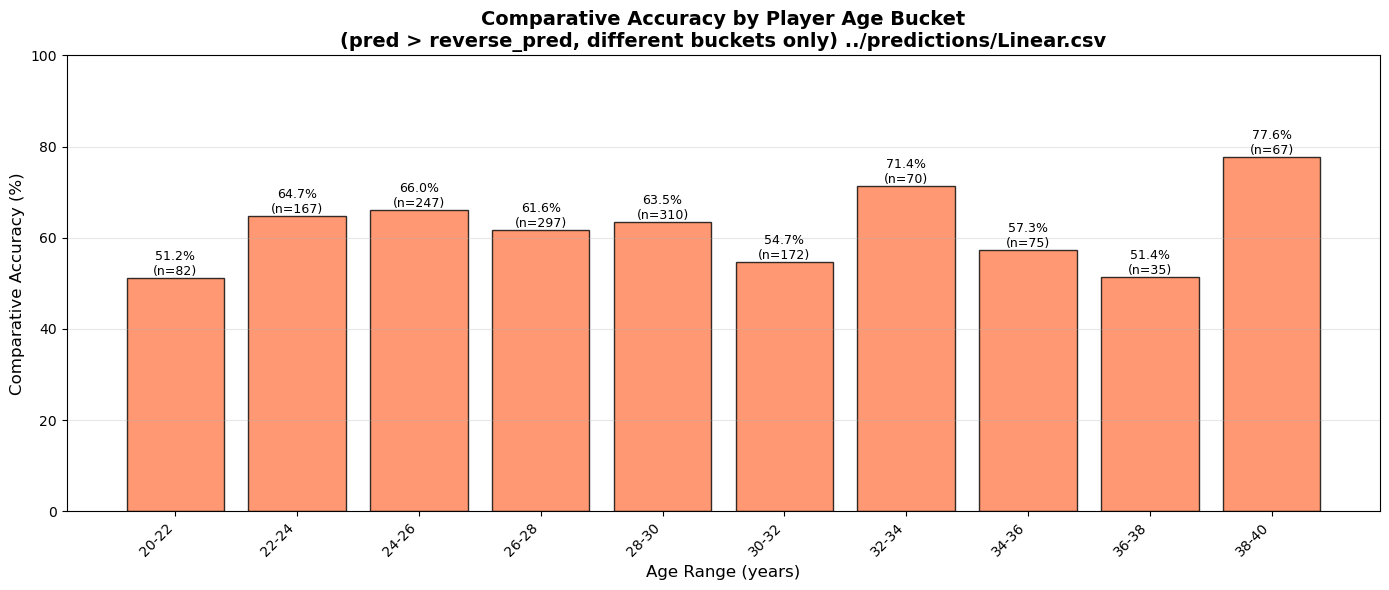

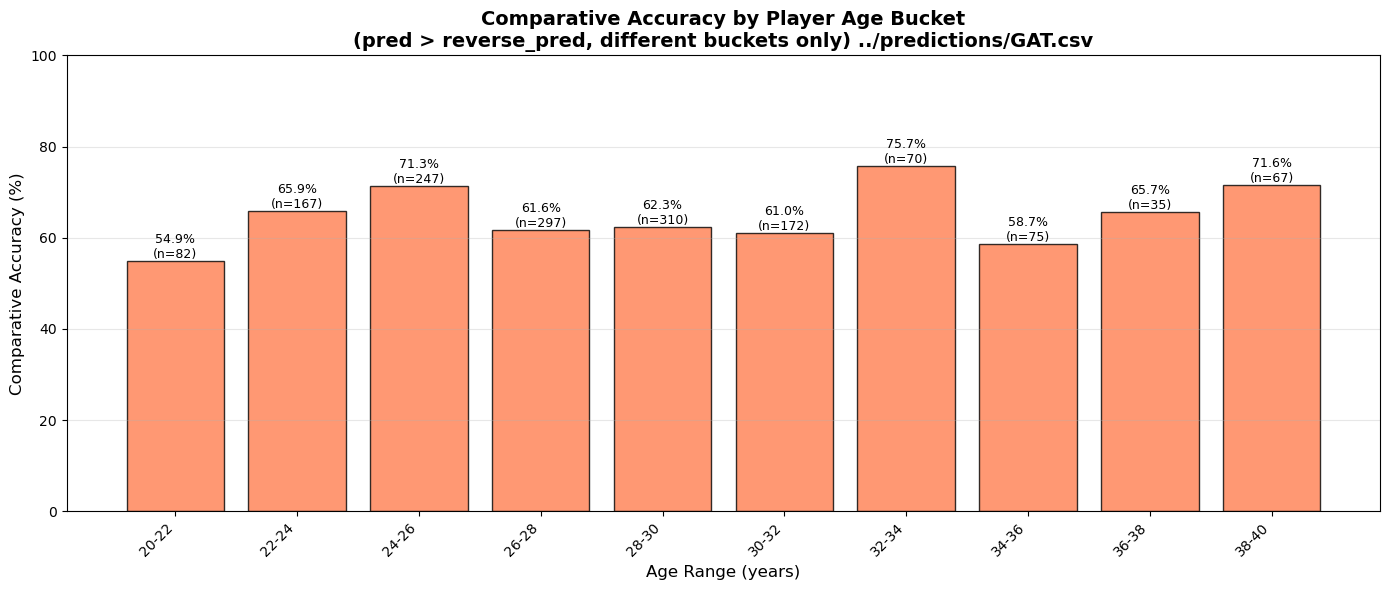

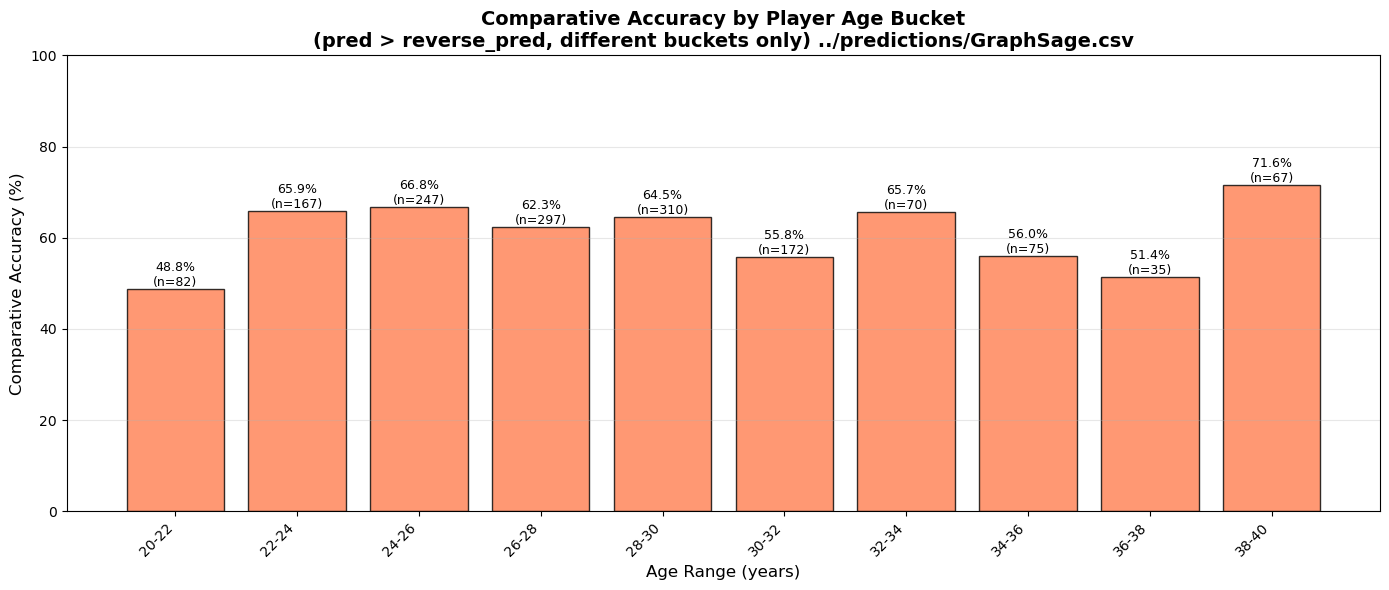

In [3]:
def plot_age_comparative_accuracy(predictions_file):
    """
    Partition players by age into 10 equal groups and calculate 
    comparative accuracy (pred > reverse_pred) for each age bucket.
    
    Args:
        predictions_file: Path to predictions CSV
    """
    # Load data
    preds = pd.read_csv(predictions_file)
    players = pd.read_csv(PLAYERS)
    
    # Convert DOB to age (assuming DOB is in YYYYMMDD format)
    from datetime import datetime
    current_year = datetime.now().year
    players['age'] = players['dob'].apply(lambda x: current_year - int(str(int(x))[:4]) if pd.notna(x) else None)
    
    # Create age lookup dictionary
    age_dict = dict(zip(players['player_id'], players['age']))
    
    # Get ages for p1 and p2
    preds['p1_age'] = preds['p1_id'].map(age_dict)
    preds['p2_age'] = preds['p2_id'].map(age_dict)
    
    # Remove rows with missing ages
    preds = preds.dropna(subset=['p1_age', 'p2_age'])
    
    # Determine if prediction was correct (pred > reverse_pred)
    preds['correct'] = preds['pred'] > preds['reverse_pred']
    
    # Create 10 equal age buckets
    min_age = players['age'].min()
    max_age = players['age'].max()
    bucket_edges = np.linspace(min_age, max_age, 11)
    bucket_labels = [f"{bucket_edges[i]:.0f}-{bucket_edges[i+1]:.0f}" 
                     for i in range(10)]
    
    # Initialize accuracy tracking for each bucket
    bucket_correct = {label: 0 for label in bucket_labels}
    bucket_total = {label: 0 for label in bucket_labels}
    
    # For each prediction, assign to buckets for both players
    for _, row in preds.iterrows():
        # Find bucket for p1
        p1_bucket_idx = np.digitize(row['p1_age'], bucket_edges) - 1
        p1_bucket_idx = max(0, min(p1_bucket_idx, 9))
        
        # Find bucket for p2
        p2_bucket_idx = np.digitize(row['p2_age'], bucket_edges) - 1
        p2_bucket_idx = max(0, min(p2_bucket_idx, 9))
        
        # Only count if players are in different buckets
        if p1_bucket_idx != p2_bucket_idx:
            is_correct = row['correct']
            
            # Add to both buckets
            bucket_total[bucket_labels[p1_bucket_idx]] += 1
            bucket_total[bucket_labels[p2_bucket_idx]] += 1
            
            if is_correct:
                bucket_correct[bucket_labels[p1_bucket_idx]] += 1
                bucket_correct[bucket_labels[p2_bucket_idx]] += 1
    
    # Calculate accuracy for each bucket
    accuracies = []
    for label in bucket_labels:
        if bucket_total[label] > 0:
            acc = (bucket_correct[label] / bucket_total[label]) * 100
        else:
            acc = 0
        accuracies.append(acc)
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x_pos = np.arange(len(bucket_labels))
    bars = ax.bar(x_pos, accuracies, color='coral', alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1f}%\n(n={bucket_total[bucket_labels[i]]})',
                ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Age Range (years)', fontsize=12)
    ax.set_ylabel('Comparative Accuracy (%)', fontsize=12)
    ax.set_title(f'Comparative Accuracy by Player Age Bucket\n(pred > reverse_pred, different buckets only) {filename}', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bucket_labels, rotation=45, ha='right')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig

for filename in prediction_files:
    fig = plot_age_comparative_accuracy(filename)
    plt.show()